# Module 2: Epidemic Modeling Template

## Team Members:
Asma Sanaullah & Melis Ozdemir

## Project Title:
*(Fill in)*

## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
This section should come from your python code after Data Release #1.

#### Code to plot early data & estimate R0

In [ ]:
#import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from pathlib import Path

# Load the data
# find the folder where the script is located
HERE = Path(__file__).parent

# build path to the csv
csv_path = HERE / "mystery_virus_daily_active_counts_RELEASE#1.csv"

data = pd.read_csv(csv_path, parse_dates=['date'])

# We have day number, date, and active cases. We can use the day number and active cases to fit an exponential growth curve to estimate R0.
# Let's define the exponential growth function
def exponential_growth(t, r):
    return np.exp(r * t)

# Fit the exponential growth model to the data. 
# We'll use a handy function from scipy called CURVE_FIT that allows us to fit any given function to our data.
# We will fit the exponential growth function to the active cases data. HINT: Look up the documentation for curve_fit to see how to use it.
# Approximate R0 using this fit 

# this extracts the day and active cases data to be used in curve fitting 
t = data['day']
cases = data['active reported daily cases']

# this is the curve_fit function which takes in the function we want to fit (exponential growth), x_data (t), and y_data (active cases)
est_params, covariance = curve_fit(exponential_growth, t, cases)
#curve_fit returns the estimated parameters (est_params) which is growth rate r0 and the covariance

est_r = est_params[0] #this is the estimated growth rate r0 from the curve fitting
print(f"Estimated growth rate (r): {est_r:.4f} per day")

t_fit = np.linspace(min(t), max(t), 100) # this creates the fitted curve to plot for x_data (days)
cases_fit = exponential_growth(t_fit, est_r) # this finds the y_data (active cases) for the fitted curve

D = 9 #9 days is infectious period 
R0 = 1 + est_r * D #estimate R0 from the growth rate r and the infectious period D
print(f"Estimated R0: {R0:.4f}")
# Add the fit as a line on top of your scatterplot.
plt.scatter(t, cases, label='Data')
plt.plot(t_fit, cases_fit, color='red', label='Exponential Fit')
plt.title('Day vs Active Infections with Exponential Fit')
plt.xlabel('Day')
plt.ylabel('Active Infections')
plt.legend()
plt.show()

#### Plot the data: day vs. active infections

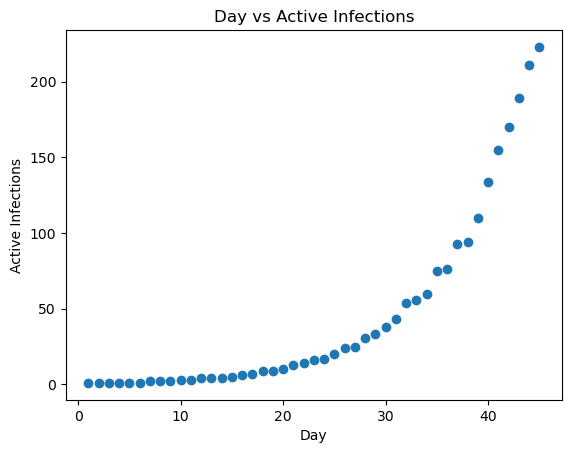

QUESTIONS TO ANSWER:


What do you notice about the initial infections?

The initial infections grow very slowly, with the curve nearly flat at the beginning. This indicates that only a small number of people are infected early on, making the outbreak appear minor at first.


How could we measure how quickly its spreading?

The speed of spread can be measured by how much the number of infections increases each day, such as the slope of the curve or the time it takes for cases to double. A steeper slope means the virus is spreading faster.


What information about the virus would be helpful in determining the shape of the outbreak curve?

Helpful information includes how contagious the virus is, how long the incubation and infectious periods are, and how people behave in response to the outbreak. These factors strongly influence how quickly the curve rises and its overall shape.

#### Fitting the exponential growth model and estimating R0 (results)
Estimated growth rate (r): 0.1214 per day

Estimated R0: 2.0930


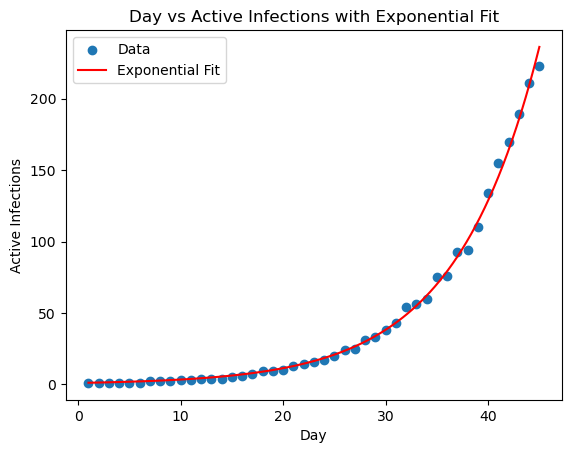


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
This section should come from your python code after Data Release #2.

In [ ]:
# Load the data
# find the folder where the script is located
HERE = Path(__file__).parent
# build path to the csv
csv_path = HERE / "mystery_virus_daily_active_counts_RELEASE#2.csv"
data = pd.read_csv(csv_path, parse_dates=['date'])
cases = data['active reported daily cases'].values

# INPUTS: beta, sigma, gamma, S0, E0, I0, R0, timepoints, N
def eulerapprox_SEIR(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):

    #Initialize S, E, I, R as empty arrays
    S = np.zeros(len(timepoints)) #np.zeros creates an array of zeros with the same length as timepoints (days)
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))

    #Set first item in each list equal to initial values  S0, E0, I0, R0
    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0

    #for each timepoint in timepoints:
    for t in range(len(timepoints) - 1): #len(timepoints) - 1 here because we are calculating the next timepoint values / the next day values, so we stop one day before the end 

    #Calculate four derivatives at timepoint
        
        # Change in susceptible population S
        dS = -beta * ((S[t] * I[t]) / N)
        
        # Change in exposed population E
        dE = (beta * ((S[t] * I[t]) / N)) - (sigma * E[t])
        
        # Change in infected population I
        dI = (sigma * E[t]) - (gamma * I[t])
        
        # Change in recovered population R
        dR = gamma * I[t]

    #Calculate S, E, I, and R at timepoint + 1 using Euler’s method ---> Use Euler's Method to calculate next day's values
    # euler's method: y(i+1) = y(i) + (dy/dt)*h ---> next value = current value + (derivative * time step) ---> h here is 1 day so we *1

        S[t+1] = S[t] + dS*1 #calculates next day's susceptible population
        E[t+1] = E[t] + dE*1 #calculates next day's exposed population
        I[t+1] = I[t] + dI*1 #calculates next day's infected population
        R[t+1] = R[t] + dR*1 #calculates next day's recovered population

    #Return S, E, I, and R
    return S, E, I, R

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

In [ ]:
#INPUTS: timepoints, N, S0, E0, I0, R0, data
def optimize_SEIR(timepoints, N, S0, E0, I0, R0, data):

    #• Initialize a range for beta, sigma, and gamma
    gamma_range = np.linspace(0.091,0.142,75) # gamma = recovery rate = 1/symptomatic period, so range of 1/11 to 1/7
    sigma_range = np.linspace(0.056,0.083,75) #sigma = incubation rate = 1/incubation period, so range of 1/18 to 1/12
    R0_est = 2.0930
    beta_range = np.linspace(0.3, 1.0, 75)
    

    #initialize an empty array of SSE
    SSE_array = []
    parameters = [] #this is list of paramters (beta, sigma, gamma) 

    #make arrays of values given each range for each parameter
    for b in beta_range:
        for s in sigma_range:
            for g in gamma_range:
                #Use euler method function you developed to calculate S, E, I, and R given those parameters
                S,E,I,R = eulerapprox_SEIR(b, s, g, S0, E0, I0, R0, timepoints, N)
                #calculate the SSE given the model results and the data and append this to the SSE array
                cases = data['active reported daily cases'].values
                SSE = np.sum((I[:len(cases)] - cases)**2)
                SSE_array.append(SSE)
                parameters.append((b, s, g)) #this adds the parameters to the list
    
    #Determine parameters corresponding to lowest SSE
    lowest_SSE = min(SSE_array)
    corres_SSE = SSE_array.index(lowest_SSE) #this finds the index of the minimum SSE in the SSE array
    best_beta, best_sigma, best_gamma = parameters[corres_SSE] #this finds the best parameters using the index of the minimum SSE

    #return best_beta, best_sigma, best_gamma and correspondsing SSE
    return best_beta, best_sigma, best_gamma, lowest_SSE

#### Plot of the SEIR Model Prediction
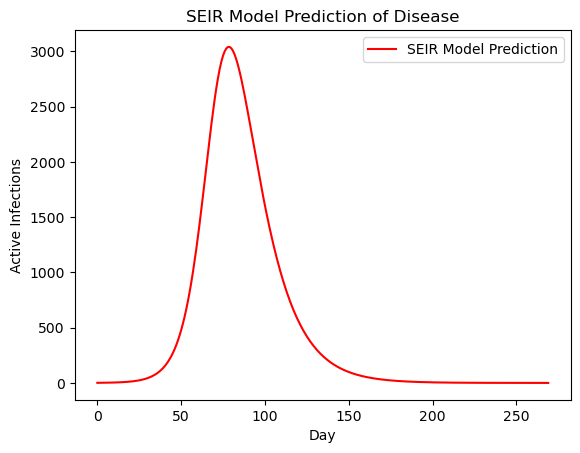

### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

In [ ]:
timepoints = np.arange(len(data)) #array of timepoints(days) 
#Set initial conditions and parameters for testing
N = 17900 #population size
I0 = data['active reported daily cases'].iloc[0] # initial infected people
E0 = 5 # initial exposed people
R0 = 0 # initial recovered people

S0 = N - I0 - E0 - R0 # initial susceptible people = total population - infected - exposed - recovered

#uses the optimize_SEIR function to find the best parameters and lowest SSE
best_beta, best_sigma, best_gamma, best_SSE = optimize_SEIR(
    timepoints, N, S0, E0, I0, R0, data
)

#print the best parameters and lowest SSE
print("Best beta:", best_beta)
print("Best sigma:", best_sigma)
print("Best gamma:", best_gamma)
print("Lowest SSE:", best_SSE)

#plots the SEIR model using the best parameters 
S, E, I, R = eulerapprox_SEIR( best_beta, best_sigma, best_gamma, S0, E0, I0, R0, timepoints, N )
plt.figure() # observed data 
plt.scatter( data['day'], data['active reported daily cases'], label="Observed Data" ) # SEIR model prediction 
plt.plot( timepoints, I, color="red", label="SEIR Model Prediction" ) 
plt.xlabel("Day") 
plt.ylabel("Active Infections") 
plt.title("SEIR Model Fit to Data") 
plt.legend() 
plt.show()

#### Best parameter results and plot
Best beta: 0.8581081081081081

Best sigma: 0.05782432432432433

Best gamma: 0.1289054054054054

Lowest SSE: 71224.72373371663


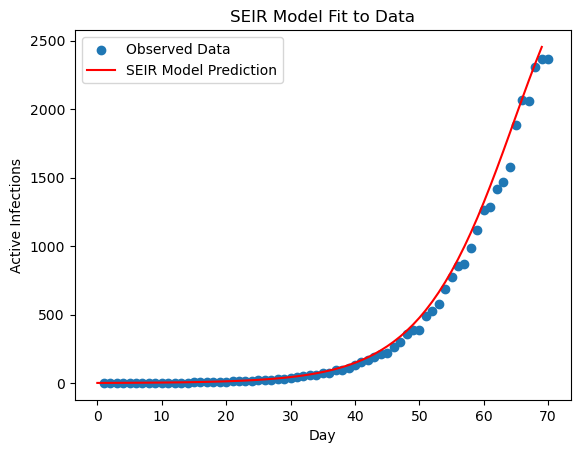

### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.


In [ ]:
#function to predict the peak using the best parameters
def predict_peak(best_beta, best_sigma, best_gamma, S0, E0, I0, R0, N):
    extra_days = len(data) + 200 #number of days to predict into the future
    time_extra = np.arange(0, extra_days) #array of timepoints 

    # uses euler function to find S,E,I,R of this extended time using the best parameters
    S, E, I, R = eulerapprox_SEIR(best_beta, best_sigma, best_gamma,
                                  S0, E0, I0, R0, time_extra, N)

    peak_value = np.max(I) #finds max value of I which is peak number of active infections
    peak_day = np.argmax(I) #finds the index of the max value of I which is the day of the peak number of active infections

    return peak_value, peak_day

#### Peak Results
Predicted peak infections: 3039.4968290416637

Predicted peak day: 78


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


In [ ]:
# Load the data
# find the folder where the script is located
HERE = Path(__file__).parent
# build path to the csv
csv_path = HERE / "mystery_virus_daily_active_counts_RELEASE#3.csv"
data = pd.read_csv(csv_path, parse_dates=['date'])
timepoints_full = np.arange(len(data))

#best parameters from optimize_SEIR function
best_beta = 0.8581081081081081
best_sigma = 0.05782432432432433
best_gamma =  0.1289054054054054

#initial conditions
N = 17900 #population size
I0 = 1 # initial infected people
E0 = 5 # initial exposed people
R0 = 0 # initial recovered people
S0 = N - I0 - E0 - R0 # initial susceptible people = total population - infected - exposed - recovered

#uses the euler method to find S,E,I,R for the full dataset using the best parameters
S_data, E_data, I_data, R_data = eulerapprox_SEIR(best_beta, best_sigma, best_gamma, S0, E0, I0, R0,
    timepoints_full,N)

plt.figure()

# full observed data
plt.scatter(
    data['day'],
    data['active reported daily cases'],
    label="Data Release #3"
)

# model prediction
plt.plot(
    timepoints_full,
    I_data,
    color="red",
    label="SEIR Model Prediction"
)

plt.xlabel("Day")
plt.ylabel("Active Infections")
plt.title("SEIR Model vs Full Dataset")
plt.legend()

plt.show()

#### Plot of dataset vs model
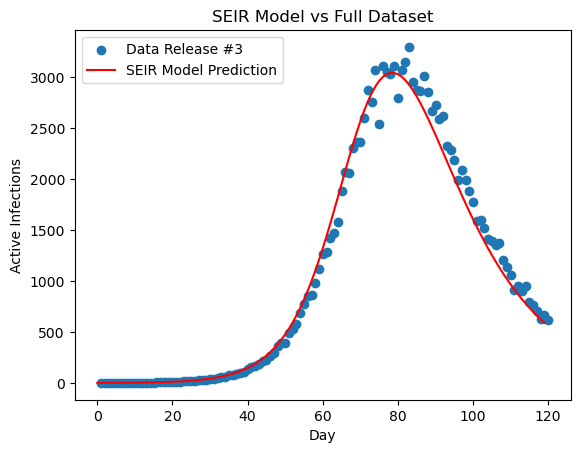

#### Relative Model Error of Data Release 3 & the SEIR Model

In [ ]:
#finding the actual peak infections and peak day from dataset 3
cases = data['active reported daily cases'].values
days = data['day'].values

peak_index = np.argmax(cases)

actual_peak_value = cases[peak_index]
actual_peak_day = days[peak_index]

print("Actual peak infections:", actual_peak_value)
print("Actual peak day:", actual_peak_day)


#True error & percent relative error

model_peak_value = 3039.4968290416637 
model_peak_day = 78

true_error_peak_value = abs(model_peak_value - actual_peak_value)
relative_error_peak_value = true_error_peak_value / actual_peak_value * 100
true_error_peak_day = abs(model_peak_day - actual_peak_day)
relative_error_peak_day = true_error_peak_day / actual_peak_day * 100
print(f"True error in peak value: {true_error_peak_value}")
print(f"Relative error in peak value: {relative_error_peak_value:.2f}%")
print(f"True error in peak day: {true_error_peak_day}")
print(f"Relative error in peak day: {relative_error_peak_day:.2f}%")

Actual peak infections: 3294

Actual peak day: 83

Model peak infections: 3039.4968

Model peak day: 78

True error in peak value: 254.50317095833634

Relative error in peak value: 7.73%

True error in peak day: 5

Relative error in peak day: 6.02%

### 2g. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.



#### Code for modeling interventions

In [ ]:
#function to model the impact of interventions
def model_SEIR(beta, sigma, gamma, S0, E0, I0, R0, days, N, intervention=None):

    #Initialize S, E, I, R as empty arrays
    S = np.zeros(len(days)) #np.zeros creates an array of zeros with the same length as timepoints (days)
    E = np.zeros(len(days))
    I = np.zeros(len(days))
    R = np.zeros(len(days))

    #Set first item in each list equal to initial values  S0, E0, I0, R0
    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0

    #masking mandate
    #Immediate masking mandate implemented from day 70 on Reduces transmission by 40%
    beta_masking = best_beta * 0.6 #new beta is 60% of UVA beta since masks reduce transmission by 40%
    masking_day = 70 #masking mandate starts on day 70

    #vaccine campaign
    #accine campaign:single event on day 70 >>> Vaccinate 2000 students on day 70 with 90% efficacy
    vaccine_day = 70 #vaccine campaign starts on day 70
    vaccine_efficacy = 0.9 #vaccine efficacy is 90% so 90% of vaccinated students will be effectively immune
    vaccinated_students = 2000 #number of students vaccinated

    #close school for 2 weeks
    #During closure, only 20% of normal contacts >>> After closure, contact rate returns to normal
    closing_days = range(70, 84) #closing for 2 weeks from day 70 to day 83
    beta_closing = best_beta * 0.2 #20% of contacts means new beta is 20% of UVA beta


    #for each timepoint in timepoints:
    for t in range(len(days) - 1): #len(timepoints) - 1 here because we are calculating the next timepoint values / the next day values, so we stop one day before the end 

        current_beta = beta # start with baseline beta
        if intervention == 'masking' and t >= masking_day: #if masking mandate is implemented and we are at the day 70, we use the new beta for masking
            current_beta = beta_masking
        if intervention == 'vaccine' and t == vaccine_day: #if vaccine campaign is implemented and we are at the day 70, vaccinated students move from susceptive to recovered based on vaccine efficacy
            vaccinated_effective = vaccinated_students * vaccine_efficacy
            S[t] = S[t] - vaccinated_effective #reduce susceptible population by number of effectively vaccinated students
            R[t] = R[t] + vaccinated_effective #increase recovered population by number of effectively vaccinated students
        if intervention == 'closure' and t in closing_days: #if school closure is implemented and we are in the 2 weeks, we use the new beta for closing
            current_beta = beta_closing
        
    #Calculate four derivatives at timepoint
        
        # Change in susceptible population S
        dS = -current_beta * ((S[t] * I[t]) / N)
        
        # Change in exposed population E
        dE = (current_beta * ((S[t] * I[t]) / N)) - (sigma * E[t])
        
        # Change in infected population I
        dI = (sigma * E[t]) - (gamma * I[t])
        
        # Change in recovered population R
        dR = gamma * I[t]

    #Calculate S, E, I, and R at timepoint + 1 using Euler’s method ---> Use Euler's Method to calculate next day's values
    # euler's method: y(i+1) = y(i) + (dy/dt)*h ---> next value = current value + (derivative * time step) ---> h here is 1 day so we *1

        S[t+1] = S[t] + dS*1 #calculates next day's susceptible population
        E[t+1] = E[t] + dE*1 #calculates next day's exposed population
        I[t+1] = I[t] + dI*1 #calculates next day's infected population
        R[t+1] = R[t] + dR*1 #calculates next day's recovered population

    #Return S, E, I, and R
    return S, E, I, R

#### Results from modeling interventions

In [ ]:
#set up parameters for VT
days = np.arange(0, 120) #array of 120 days to model interventions
N_VT = 31000  # VT student population
E0_VT= E0_UVA = 5 
I0 = data['active reported daily cases'].iloc[0]
R0 = 0
S0 = N_VT - I0 - E0_VT - R0

#best parameters from optimize_SEIR function
best_beta = 0.8581081081081081
best_sigma = 0.05782432432432433
best_gamma =  0.1289054054054054

#model the SEIR with each intervention and find the peak infections for each intervention
S_masking, E_masking, I_masking, R_masking = model_SEIR(best_beta, best_sigma, best_gamma, S0, E0_VT, I0, R0,
    days,N_VT, intervention='masking')
S_vaccine, E_vaccine, I_vaccine, R_vaccine = model_SEIR(best_beta, best_sigma, best_gamma, S0, E0_VT, I0, R0,
    days,N_VT, intervention='vaccine')
S_closure, E_closure, I_closure, R_closure = model_SEIR(best_beta, best_sigma, best_gamma, S0, E0_VT, I0, R0,
    days,N_VT, intervention='closure')

#print the peak infections for each intervention
print (f"Peak infections with masking intervention: {max(I_masking)}")
print (f"Peak infections with vaccine intervention: {max(I_vaccine)}")
print (f"Peak infections with closure intervention: {max(I_closure)}")

#model the SEIR with no intervention to find the baseline peak infections and print
S_baseline, E_baseline, I_baseline, R_baseline = model_SEIR(best_beta, best_sigma, best_gamma, S0, E0_VT, I0, R0,
    days,N_VT)
print (f"Peak infections with no intervention: {max(I_baseline)}")

#finding cases prevented between 70 to 120 days 
cases_prevented_masking = (R_baseline[-1] + I_baseline[-1]) - (R_baseline[69] + I_baseline[69]) \
                          - ((R_masking[-1] + I_masking[-1]) - (R_masking[69] + I_masking[69]))

cases_prevented_vaccine = (R_baseline[-1] + I_baseline[-1]) - (R_baseline[69] + I_baseline[69]) \
                          - ((R_vaccine[-1] + I_vaccine[-1]) - (R_vaccine[69] + I_vaccine[69]))
cases_prevented_closure = (R_baseline[-1] + I_baseline[-1]) - (R_baseline[69] + I_baseline[69]) \
                          - ((R_closure[-1] + I_closure[-1]) - (R_closure[69] + I_closure[69]))

print (f"Total cases prevented with masking intervention: {cases_prevented_masking}")
print (f"Total cases prevented with vaccine intervention: {cases_prevented_vaccine}")
print (f"Total cases prevented with closure intervention: {cases_prevented_closure}")

Peak infections with masking intervention: 4729.809974648401

Peak infections with vaccine intervention: 4962.844223616479

Peak infections with closure intervention: 4189.362639247548

Peak infections with no intervention: 5266.041785146047

Total cases prevented with masking intervention: 906.7243740585036

Total cases prevented with vaccine intervention: -146.79726756906894

Total cases prevented with closure intervention: 1279.9687117854992

## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*